# 篇末综合：非线性行为与证据边界

## 学习目标与先修知识

能综合六章证据，分别核对集合吸引、定向返回、离散与连续增长及 Lorenz 有界性，限定稳定性与混沌（chaos）结论。

先修：本篇 4.1—4.6，尤其点到集合距离、同向截面插值与切向扰动；各题独立给出所需输入（input）。

In [ ]:
from systems_science.local_service import notebook_service_ready
notebook_service_ready()

## 六章综合的证据路线

先判断吸引的是点还是集合，再核对振荡来源与分岔（bifurcation）条件；对给定轨迹（trajectory）采用固定方向提取截面，把离散每步增长和连续每时间增长分开。最后对 Lorenz 的 W 用两条代数路径求导，说明有界、体积收缩、方向伸长各自支持什么。以下二维区域实验连接第 4.5 章的稳定性条件与本篇的证据比较。

## 具体问题

面对一个“会切换、会振荡、还可能不规则”的生命系统，怎样避免只凭一条图选择解释？本单元给出开关、径向振子、离散映射和 Lorenz 四类模型（model）任务，每个问题独立输入（input），最后用稳定性条件检查结论边界。

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from systems_science import plot_style, show_table
plot_style()
BLUE, PINK, GREEN, GRAY = '#008bfb', '#ff0051', '#009e73', '#555555'

## 初步实验

In [2]:
display(Markdown(show_table(['要回答的问题','应控制的条件','独立依据'],[
('切换是否来自多稳态','参数固定、改变初值','平衡与流向'),
('周期是否长期存在','输入、暂态、采样','径向方程与事件规则'),
('误差何时影响预测','初值差、阈值、精度','映射差值与高精度对照'),
('能否论证区域恢复','候选函数与定义域','沿轨迹导数的不等式')
])))

| 要回答的问题 | 应控制的条件 | 独立依据 |
| --- | --- | --- |
| 切换是否来自多稳态 | 参数固定、改变初值 | 平衡与流向 |
| 周期是否长期存在 | 输入、暂态、采样 | 径向方程与事件规则 |
| 误差何时影响预测 | 初值差、阈值、精度 | 映射差值与高精度对照 |
| 能否论证区域恢复 | 候选函数与定义域 | 沿轨迹导数的不等式 |

## 模型假设

案例一为 x′=x−x³，案例二为 μ=0.5、ω=1 的径向振子，案例三为 r=3.9 的 logistic 映射（logistic map），案例四为 σ=10、ρ=28、β=8/3 的洛伦兹系统（Lorenz system），作为来源明确的对流基准。它们分别是调控开关、节律和代次更新的理想类比，并非同一个已识别的生理模型。

所有状态（state）均按各自定义归一，连续模型的 τ 是无量纲（dimensionless）时间，映射的 n 是代次。各题按其模型定义解释数值与单位。综合练习各题携带完整条件，前题答案不是后题输入；普通章节练习不计入本题组 100 分。

## 数学解释与推导

先把问题分类，再选择证据。

1. **平衡（equilibrium）与吸引域（basin of attraction）**：解析 f=0 和流向限制可能去向，数值扫描检查指定初值（initial condition）和观察窗。中点更新要保留半步预测；阈值恰等时不算严格越过。精确不稳定平衡与邻近轨迹（trajectory）不能混为一谈。
2. **节律**：极限环（limit cycle）半径来自 R′=R(μ−R²)，周期来自 θ′=ω。观测（observation）事件法必须固定方向、插值和暂态（transient）；足够周期数与步长对照帮助识别采样误差。半径恢复不自动校正相位（phase）。
3. **预测范围**：两条映射轨迹的距离从第 0 代开始，越界期限依赖阈值。把十进制字符串直接交给 Decimal，保留精度和运算顺序；有限时间扩张与不规则曲线都属于有限证据，不自动成为所有初值的长期性质。
4. **区域论证**：正定（positive definite） V 与 V′ 的符号需覆盖声明区域，再借紧子水平集（sublevel set）保持轨迹在区域内。对新二维模型，s=x²+y² 下 V′≤s(s−min(a,b)) 给出可迁移的充分条件 R²≤min(a,b)。

5. **连续返回与增长**：对 $z_i<c\le z_{i+1}$，用同一个 $\alpha=(c-z_i)/(z_{i+1}-z_i)$ 计算时间和状态交点；完整截面与单坐标投影（projection）不同。离散增长是 $\sum\log|f'|/n$，连续增长是 $\sum\log s_i/\sum\Delta t_i$，必须标明单位。
6. **有界性与证据**：Lorenz 的 $W=\rho x^2+\sigma y^2+\sigma(z-2\rho)^2$ 满足 $\dot W=-2\sigma[\rho x^2+y^2+\beta(z-\rho)^2-\beta\rho^2]$，进而得到 $\dot W\le-cW+C$。这个区域界既不宣称所有方向都收缩，也不替代平衡稳定或混沌存在性证明。下方三幅图复习原三类问题；连续时间的定向事件和函数恒等式在新增练习中独立核对。

把每个结论与它的依据相接：平衡由方程求得，区域由导数（derivative）符号确定，有限窗口内的分离由轨迹计算得到。

本题组按基础辨析、方法应用、综合验证、迁移挑战递进，各题独立判定。做完后从最早未掌握的层次返回对应章节，而不只比较总分。

## 核心实现

将推导中的每一步明确写成计算。

In [3]:
def switch_step(state,bias,h):
    first=state-state**3+bias
    middle=state+h*first/2
    return state+h*(middle-middle**3+bias)

def switch_path(initial,bias,h,steps):
    values=[initial]
    for _ in range(steps):
        values.append(switch_step(values[-1],bias,h))
    return values

def basin_scan(initials,h,steps,threshold):
    final=[switch_path(x,0,h,steps)[-1] for x in initials]
    labels=[-1 if x < -threshold else 1 if x > threshold else 0 for x in final]
    return final,labels

def radial_exact(mu,omega,initial,times):
    square=initial[0]**2+initial[1]**2
    if square==0:return [[0.,0.] for _ in times]
    states=[]
    for t in times:
        if mu==0:
            radius_square=square/(1+2*square*t)
        else:
            exponent=math.exp(2*mu*t)
            radius_square=square*exponent/(1+square*math.expm1(2*mu*t)/mu)
        scale=math.sqrt(radius_square/square)
        cosine,sine=math.cos(omega*t),math.sin(omega*t)
        states.append([scale*(initial[0]*cosine-initial[1]*sine),scale*(initial[0]*sine+initial[1]*cosine)])
    return states

def crossing_summary(values,dt,start):
    crossings=[]
    for i in range(start,len(values)-1):
        if values[i]<=0<values[i+1]:
            crossings.append((i-values[i]/(values[i+1]-values[i]))*dt)
    period=(crossings[-1]-crossings[0])/(len(crossings)-1) if len(crossings)>=2 else None
    return crossings,period

def precision_separation(r_text,first_text,second_text,steps,precision,threshold):
    from decimal import Decimal,localcontext
    x,y=float(first_text),float(second_text)
    binary=[abs(x-y)]
    for _ in range(steps):
        x=float(r_text)*x*(1-x);y=float(r_text)*y*(1-y)
        binary.append(abs(x-y))
    with localcontext() as context:
        context.prec=precision
        r=Decimal(r_text);a=Decimal(first_text);b=Decimal(second_text)
        decimal=[float(abs(a-b))]
        for _ in range(steps):
            a=r*a*(1-a);b=r*b*(1-b)
            decimal.append(float(abs(a-b)))
    first=lambda values:next((i for i,d in enumerate(values) if d>threshold),None)
    return binary,decimal,first(binary),first(decimal)

def regional_energy(points,a,b,radius):
    values=[];derivatives=[];strict=[]
    for x,y in points:
        square=x*x+y*y
        values.append(square/2)
        derivative=-a*x*x-b*y*y+square*square
        derivatives.append(derivative)
        strict.append(0<square<radius*radius and derivative<0)
    # A sufficient certificate on the full open disk, using the weakest damping.
    certificate=radius*radius<=min(a,b)
    return values,derivatives,strict,certificate

## 对照实验

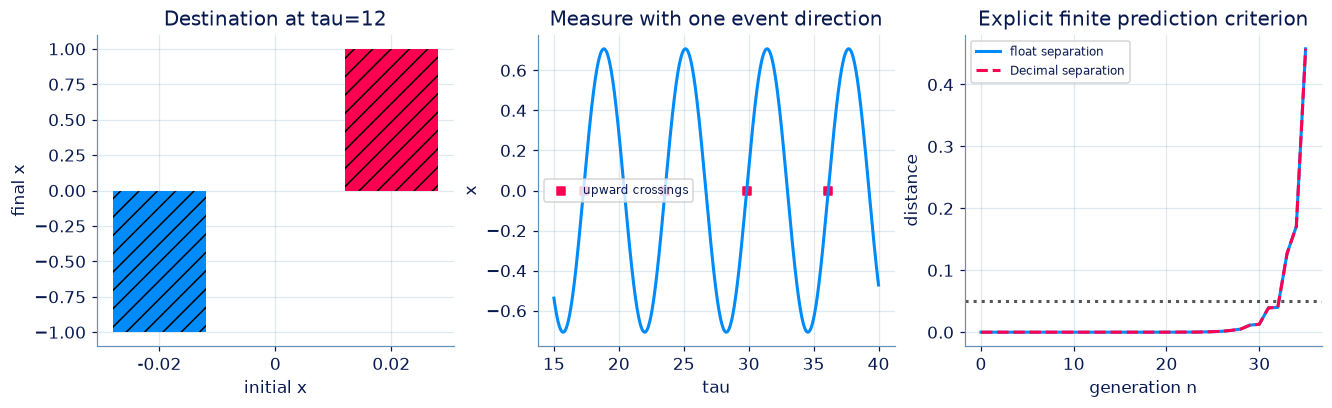

去向标签 [-1, 0, 1] ；事件周期 6.2831853065589165 ；两种精度首次越界 33 33


In [4]:
initials=[-.02,0,.02]
final,labels=basin_scan(initials,.01,1200,.9)
times=np.arange(4001)*.01
states=np.array(radial_exact(.5,1,[.2,0],times))
events,period=crossing_summary(states[:,0],.01,1500)
binary,decimal,first_a,first_b=precision_separation('3.9','.2','.200000001',35,40,.05)
fig,axes=plt.subplots(1,3,figsize=(12,3.6))
axes[0].bar(range(3),final,color=[BLUE,GRAY,PINK],hatch='//')
axes[0].set(xticks=range(3),xticklabels=['-0.02','0','0.02'],xlabel='initial x',ylabel='final x',title='Destination at tau=12')
mask=times>=15;axes[1].plot(times[mask],states[mask,0],color=BLUE)
axes[1].scatter(events,[0]*len(events),color=PINK,marker='s',s=25,label='upward crossings')
axes[1].set(xlabel='tau',ylabel='x',title='Measure with one event direction');axes[1].legend(fontsize=8)
axes[2].plot(binary,color=BLUE,label='float separation')
axes[2].plot(decimal,color=PINK,ls='--',label='Decimal separation')
axes[2].axhline(.05,color=GRAY,ls=':')
axes[2].set(xlabel='generation n',ylabel='distance',title='Explicit finite prediction criterion');axes[2].legend(fontsize=8)
plt.show()
print('去向标签',labels,'；事件周期',period,'；两种精度首次越界',first_a,first_b)

## 结果解释

三幅图各自的横纵轴都完整说明语义：第一幅是给定时间的末态，第二幅是事件定义，第三幅是有限代次距离。它们没有共用一个含糊的“系统得分”。

先用解析依据检查例子，再完成下面八题。若数值实验与推导不符，应检查更新顺序、输入范围、事件下标和窗口；不要直接调整图像到“应该的样子”。

### 独立核对

保留零平衡、解析周期和全区域充分不等式等独立依据，避免综合任务只检查函数间是否互相一致。

In [5]:
assert labels==[-1,0,1]
assert abs(period-2*np.pi)<1e-5
assert len(binary)==len(decimal)==36
_,derivatives,inside,certificate=regional_energy([[.2,.3],[0,0]],.5,.8,.7)
assert certificate and derivatives[0]<0 and inside==[True,False]
print('三类模型与区域证书分别通过，结论不跨越各自条件。')

三类模型与区域证书分别通过，结论不跨越各自条件。


## 练习与参考资料

先独立作答，再提交核对。

本篇综合题按基础辨析、方法应用、综合验证、迁移挑战递进，共 100 分。每题独立作答；正确选择或完整测试通过得该题全部分值。网页分别汇总首次作答分与练习达成分，支持按层次和学习目标复习。

### 第 1 题 · 基础辨析 · 10 分 · 多项选择题：吸引子、吸引域与轨迹

比较 x′=x−x³、稳定单位圆模型（model）与纯旋转。哪些陈述成立？

- **A.** 开关的 +1 吸引所有正初值（initial condition）。
- **B.** 稳定周期轨道是整个不变集（invariant set）合，不是某一固定相位（phase）点。
- **C.** 纯旋转的任意圆都吸引周围轨迹（trajectory）。
- **D.** 画一条轨迹就完整给出了吸引域（basin of attraction）。

[作答：吸引子、吸引域与轨迹](http://127.0.0.1:8000/parts/04-%E9%9D%9E%E7%BA%BF%E6%80%A7%E5%8A%A8%E6%80%81%E8%A1%8C%E4%B8%BA/%E7%BB%BC%E5%90%88%E7%BB%83%E4%B9%A0/practice/?question=p04-cap-equilibrium)

### 第 2 题 · 基础辨析 · 10 分 · 多项选择题：振荡来源与参数转变

改变外部输入（input）和参数（parameter）后观察振荡。哪些判断合理？

- **A.** 撤去周期输入后衰减的例子可属于受迫振荡（forced oscillation）。
- **B.** 自治径向模型（model） R′=μR−R³、θ′=1 在 μ>0 有稳定周期。
- **C.** 有限扫描的跳变点必然等于解析折叠点。
- **D.** 延长暂态（transient）等待可检查临界减慢造成的偏差。

[作答：振荡来源与参数转变](http://127.0.0.1:8000/parts/04-%E9%9D%9E%E7%BA%BF%E6%80%A7%E5%8A%A8%E6%80%81%E8%A1%8C%E4%B8%BA/%E7%BB%BC%E5%90%88%E7%BB%83%E4%B9%A0/practice/?question=p04-cap-source)

### 第 3 题 · 方法应用 · 15 分 · Python 计算题：复算多初值扫描的有限结果

对 x′=x−x³，按明确的显式中点积分和阈值规则返回末态与分类。包含恰好在不稳定平衡（equilibrium）及接近边界的初值（initial condition）。

**函数与代码模板**

```python
def solve(
    initials: list[float],
    h: float,
    steps: int,
    threshold: float,
) -> tuple[list[float], list[int]]:
    # 根据已知条件计算，并按约定顺序返回。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `initials` | `list[float]` | 给定初值列表。 | 1 |
| `h` | `float` | 时间步长（time step）。 | 1 |
| `steps` | `int` | 固定积分（definite integral）步数。 | 1 |
| `threshold` | `float` | 有限时间分类阈值。 | 1 |

**返回值**

按以下顺序返回元组：(final_states, labels)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `final_states` | `list[float]` | 各初值末态。 | 1 |
| `labels` | `list[int]` | 小于负阈值 −1，大于正阈值 1，其余 0。 | 1 |

**计算规则**

每步 m=x+h*(x−x³)/2，再令 x←x+h*(m−m³)。恰做 steps 步。分类使用严格不等式。

**约束与边界**

- 所有输入（input）数值有限；不修改输入列表。
- 1≤len(initials)≤20；各项在 [−1.5,1.5]；0<h≤0.05；0≤steps≤3000；0<threshold<1。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| initials | 给定初值列表。 | [-0.8, 0, 0.8] | 1 |
| h | 时间步长（time step）。 | 0.01 | 1 |
| steps | 固定积分（definite integral）步数。 | 0 | 1 |
| threshold | 有限时间分类阈值。 | 0.8 | 1 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
initials = [-0.8, 0, 0.8]
h = 0.01
steps = 0
threshold = 0.8

result = solve(initials, h, steps, threshold)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| final_states | 各初值末态。 | [-0.8, 0, 0.8] | 1 |
| labels | 小于负阈值 −1，大于正阈值 1，其余 0。 | [0, 0, 0] | 1 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = ([-0.8, 0, 0.8], [0, 0, 0])
```

**样例解释**

零步返回原初值，±0.8 恰等于阈值，不是严格越界，所以所有标签为 0。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：复算多初值扫描的有限结果](http://127.0.0.1:8000/parts/04-%E9%9D%9E%E7%BA%BF%E6%80%A7%E5%8A%A8%E6%80%81%E8%A1%8C%E4%B8%BA/%E7%BB%BC%E5%90%88%E7%BB%83%E4%B9%A0/practice/?question=p04-cap-basins)

### 第 4 题 · 方法应用 · 15 分 · Python 计算题：从定向截面计算返回

对给定周期或 Lorenz 轨迹（trajectory），按相同的方向、暂态（transient）阈值与插值规则提取交点及间隔。各输入（input）已经完整给定，不依赖其他题。

**函数与代码模板**

```python
def solve(
    times: list[float],
    states: list[list[float]],
    level: float,
    burn: float,
) -> tuple[list[list[float]], list[float]]:
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `times` | `list[float]` | 严格递增的观测（observation）时刻。 | τ |
| `states` | `list[list[float]]` | 与时刻一一对应的三维状态（state）。 | 1 |
| `level` | `float` | 截面高度 c。 | 1 |
| `burn` | `float` | 保留交点的起始时间，含等号。 | τ |

**返回值**

按以下顺序返回元组：(hits, intervals)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `hits` | `list[list[float]]` | 交点列表，每行 [t,x,y,z]；时间单位 τ，其余无量纲（dimensionless）。 | 1 |
| `intervals` | `list[float]` | 相邻保留交点的时间差。 | τ |

**计算规则**

只接受 states[i][2]<level≤states[i+1][2]。用 α=(level−zᵢ)/(zᵢ₊₁−zᵢ) 对时间和三个状态线性插值，仅保留 t≥burn。返回 (hits,intervals)；无交点时均为空列表，只有一个交点时 intervals 为空。端点从下方到达记一次，下一段从等号出发不重复记。

**约束与边界**

- 所有数值有限，不修改输入列表。
- 2≤len(times)=len(states)≤200；每个状态长度 3；时间严格递增；所有状态和时刻绝对值≤100；burn≥0。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| times | 严格递增的观测（observation）时刻。 | [0, 1, 2, 3] | τ |
| states | 与时刻一一对应的三维状态（state）。 | [[0, 0, -1], [2, 4, 1], [4, 8, -1], [6, 12, 1]] | 1 |
| level | 截面高度 c。 | 0 | 1 |
| burn | 保留交点的起始时间，含等号。 | 0 | τ |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
times = [0, 1, 2, 3]
states = [[0, 0, -1], [2, 4, 1], [4, 8, -1], [6, 12, 1]]
level = 0
burn = 0

result = solve(times, states, level, burn)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| hits | 交点列表，每行 [t,x,y,z]；时间单位 τ，其余无量纲（dimensionless）。 | [[0.5, 1.0, 2.0, 0.0], [2.5, 5.0, 10.0, 0.0]] | 1 |
| intervals | 相邻保留交点的时间差。 | [2.0] | τ |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = ([[0.5, 1.0, 2.0, 0.0],
                    [2.5, 5.0, 10.0, 0.0]],
                   [2.0])
```

**样例解释**

两个同向交点为 [0.5,1,2,0] 和 [2.5,5,10,0]，返回间隔为 2。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-08。

[作答：从定向截面计算返回](http://127.0.0.1:8000/parts/04-%E9%9D%9E%E7%BA%BF%E6%80%A7%E5%8A%A8%E6%80%81%E8%A1%8C%E4%B8%BA/%E7%BB%BC%E5%90%88%E7%BB%83%E4%B9%A0/practice/?question=p04-cap-period)

### 第 5 题 · 综合验证 · 15 分 · Python 计算题：离散与连续的扰动增长

同时给定离散映射的逐步导数（derivative）和连续切向段伸长，分别计算有限增长率。零映射导数使本题离散对数和为负无穷，用 None 表示。

**函数与代码模板**

```python
def solve(
    map_derivatives: list[float],
    stretch_factors: list[float],
    durations: list[float],
) -> tuple[float | None, float]:
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `map_derivatives` | `list[float]` | 逐步映射导数，可为零或负。 | 1 |
| `stretch_factors` | `list[float]` | 每段终点范数（norm）除以该段起点范数，均正。 | 1 |
| `durations` | `list[float]` | 与每段对应的实际时长。 | τ |

**返回值**

按以下顺序返回元组：(per_step, per_time)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `per_step` | <code>float &#124; None</code> | 平均 log&#124;导数&#124;；遇零返回 None。 | 每步 |
| `per_time` | `float` | 连续段平均增长率。 | 每单位 τ |

**计算规则**

离散结果=sum(log(abs(d)))/映射步数，若任一 d=0 则 None；连续结果=sum(log(s))/sum(dt)。返回 (per_step,per_time)。

**约束与边界**

- 所有数值有限，不修改输入（input）列表。
- 各序列长度 1—100；连续两列表等长；伸长及时间严格为正；各非零导数和伸长绝对值在 [1e−8,1e8]。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| map_derivatives | 逐步映射导数，可为零或负。 | [2, -0.5] | 1 |
| stretch_factors | 每段终点范数（norm）除以该段起点范数，均正。 | [2, 0.5, 4] | 1 |
| durations | 与每段对应的实际时长。 | [1, 1, 2] | τ |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
map_derivatives = [2, -0.5]
stretch_factors = [2, 0.5, 4]
durations = [1, 1, 2]

result = solve(map_derivatives, stretch_factors, durations)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| per_step | 平均 log|导数|；遇零返回 None。 | 0 | 每步 |
| per_time | 连续段平均增长率。 | ≈ 0.3465736 | 每单位 τ |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = (0.0, 0.34657359027997264)
```

**样例解释**

离散两步净放大为 1，结果为 0/步；连续净放大为 4，总时长 4，结果 ln(4)/4。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-08。

[作答：离散与连续的扰动增长](http://127.0.0.1:8000/parts/04-%E9%9D%9E%E7%BA%BF%E6%80%A7%E5%8A%A8%E6%80%81%E8%A1%8C%E4%B8%BA/%E7%BB%BC%E5%90%88%E7%BB%83%E4%B9%A0/practice/?question=p04-cap-precision)

### 第 6 题 · 综合验证 · 15 分 · 单项选择题：混沌证据是否充分

已保留精确平衡（equilibrium），普通初值（initial condition）在细化短窗中收敛，长窗截面与增长率仍随窗口变化。应该怎样报告？

- **A.** 列出参数（parameter）、初值、步长、暂态（transient）、窗口及差异，作为有限数值证据。
- **B.** 删去精确平衡以声称所有初值敏感。
- **C.** 一次正增长就是严格混沌（chaos）证明。
- **D.** 只凭轨迹（trajectory）形状就确定分形维数（fractal dimension）。

[作答：混沌证据是否充分](http://127.0.0.1:8000/parts/04-%E9%9D%9E%E7%BA%BF%E6%80%A7%E5%8A%A8%E6%80%81%E8%A1%8C%E4%B8%BA/%E7%BB%BC%E5%90%88%E7%BB%83%E4%B9%A0/practice/?question=p04-cap-irregular)

### 第 7 题 · 迁移挑战 · 10 分 · Python 计算题：有界性与函数导数的双重核对

给定 Lorenz 参数（parameter）与状态（state），以同一个 W 分别计算链式导数（derivative）和配方导数，给出正 c 与 C。这些量可用于估计轨迹（trajectory）可达范围的上界。

**函数与代码模板**

```python
def solve(
    sigma: float,
    rho: float,
    beta: float,
    state: list[float],
) -> tuple[float, float, float, float, float]:
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `sigma` | `float` | 正参数（parameter） σ。 | 1 |
| `rho` | `float` | 正参数 ρ。 | 1 |
| `beta` | `float` | 正参数 β。 | 1 |
| `state` | `list[float]` | 状态（state） [x,y,z]。 | 1 |

**返回值**

按以下顺序返回元组：(W, direct, completed, c, C)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `W` | `float` | 有界性函数值。 | 1 |
| `direct` | `float` | 梯度（gradient）与向量场（vector field）内积（inner product）。 | 每单位 τ |
| `completed` | `float` | 配方后导数值。 | 每单位 τ |
| `c` | `float` | 正衰减系数。 | 每单位 τ |
| `C` | `float` | 界中常数。 | 每单位 τ |

**计算规则**

W=ρx²+σy²+σ(z−2ρ)²；direct=∇W·f；completed=−2σ[ρx²+y²+β(z−ρ)²−βρ²]；c=min(2σ,2,β)，C=4σβρ²。分别计算两种导数表达式，返回 (W,direct,completed,c,C)。

**约束与边界**

- 所有数值有限，不修改输入（input）列表。
- 0<σ≤20，0<ρ≤40，0<β≤5；状态各分量绝对值≤60。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| sigma | 正参数（parameter） σ。 | 10 | 1 |
| rho | 正参数 ρ。 | 2 | 1 |
| beta | 正参数 β。 | 1 | 1 |
| state | 状态（state） [x,y,z]。 | [0, 0, 0] | 1 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
sigma = 10
rho = 2
beta = 1
state = [0, 0, 0]

result = solve(sigma, rho, beta, state)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| W | 有界性函数值。 | 160 | 1 |
| direct | 梯度（gradient）与向量场（vector field）内积（inner product）。 | 0 | 每单位 τ |
| completed | 配方后导数值。 | 0 | 每单位 τ |
| c | 正衰减系数。 | 1 | 每单位 τ |
| C | 界中常数。 | 160 | 每单位 τ |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = (160, 0, 0, 1, 160)
```

**样例解释**

原点两种导数为零；W=160、c=1、C=160。导数非负的局部时刻并不破坏 W′≤−cW+C。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-08。

[作答：有界性与函数导数的双重核对](http://127.0.0.1:8000/parts/04-%E9%9D%9E%E7%BA%BF%E6%80%A7%E5%8A%A8%E6%80%81%E8%A1%8C%E4%B8%BA/%E7%BB%BC%E5%90%88%E7%BB%83%E4%B9%A0/practice/?question=p04-cap-region)

### 第 8 题 · 迁移挑战 · 10 分 · 多项选择题：吸引、稳定与混沌的结论边界

已解析得到 W′≤−cW+C（c>0），散度（divergence）为负，并得到有限窗口正增长。哪些结论有依据？

- **A.** 由积分因子可给出 W(t) 的上界。
- **B.** 足够大的 W 子水平集（sublevel set）约束最终轨迹（trajectory）范围。
- **C.** 所有方向都收缩，所有解趋于同一平衡（equilibrium）。
- **D.** 还不能仅凭这三条宣称完成奇异吸引子（strange attractor）严格存在性证明。

[作答：吸引、稳定与混沌的结论边界](http://127.0.0.1:8000/parts/04-%E9%9D%9E%E7%BA%BF%E6%80%A7%E5%8A%A8%E6%80%81%E8%A1%8C%E4%B8%BA/%E7%BB%BC%E5%90%88%E7%BB%83%E4%B9%A0/practice/?question=p04-cap-scope)